In [5]:
from sklearn.datasets import make_moons
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
X,y =make_moons(100, noise=0.25,random_state=2)

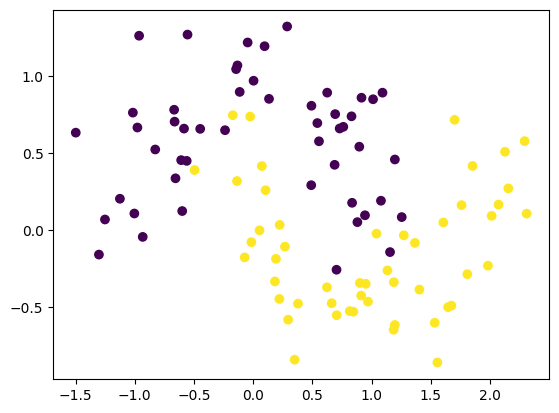

In [6]:
plt.scatter(X[:,0],X[:,-1],c=y)

In [7]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [15]:
model = Sequential()
model.add(Dense(2,activation='sigmoid',input_dim=2))
model.add(Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 2)                 6         
                                                                 
 dense_3 (Dense)             (None, 1)                 3         
                                                                 
Total params: 9
Trainable params: 9
Non-trainable params: 0
_________________________________________________________________


In [17]:
initial_weights = model.get_weights()

In [18]:
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [19]:
model.set_weights(initial_weights)

In [20]:
model.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [21]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [22]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 2s 75ms/step - loss: 0.8166 - accuracy: 0.5375 - val_loss: 1.0153 - val_accuracy: 0.3500
Epoch 2/100
3/3 [==============================] - 0s 16ms/step - loss: 0.8147 - accuracy: 0.5375 - val_loss: 1.0120 - val_accuracy: 0.3500
Epoch 3/100
3/3 [==============================] - 0s 16ms/step - loss: 0.8127 - accuracy: 0.5375 - val_loss: 1.0088 - val_accuracy: 0.3500
Epoch 4/100
3/3 [==============================] - 0s 15ms/step - loss: 0.8110 - accuracy: 0.5375 - val_loss: 1.0056 - val_accuracy: 0.3500
Epoch 5/100
3/3 [==============================] - 0s 19ms/step - loss: 0.8089 - accuracy: 0.5375 - val_loss: 1.0024 - val_accuracy: 0.3500
Epoch 6/100
3/3 [==============================] - 0s 18ms/step - loss: 0.8070 - accuracy: 0.5375 - val_loss: 0.9993 - val_accuracy: 0.3500
Epoch 7/100
3/3 [==============================] - 0s 17ms/step - loss: 0.8052 - accuracy: 0.5375 - val_loss: 0.9961 - val_accuracy: 0.3500
Epoch 8/100
3/3 [===

In [23]:
model.get_weights()

[array([[0.7253177, 0.7253177],
        [0.2444211, 0.2444211]], dtype=float32),
 array([0.27823892, 0.27823892], dtype=float32),
 array([[0.2760104],
        [0.2760104]], dtype=float32),
 array([0.25867704], dtype=float32)]

9600/9600 [==============================] - 9s 889us/step


<Axes: >

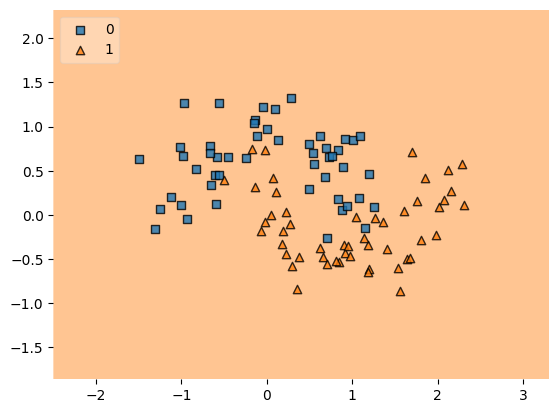

In [26]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'),clf=model,legend=2)